In [6]:
import scipy as sp
from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones
import torch
from numpy import pi, exp, conj, min, argmin, unravel_index, log
import warnings
warnings.filterwarnings("ignore")

In [22]:
def hl2_prime(n, z):
    return (n / z) * hankel2(n, z) - hankel2(n + 1, z) # derivative for hankel function of second kind
def hl1_prime(n, z):
    return (n / z) * hankel1(n, z) - hankel1(n + 1, z) # derivative for hankel function of first kind
def hl1_asymptotic(n, z):
    #return sqrt(2/(pi*z))*np.exp(1j*(z-pi/4))*(-1j)**n
    return sqrt(1/(pi*z))*(1-1j)*exp(1j*z)*(-1j)**n
def hl2_asymptotic(n, z):
    return conj(hl1_asymptotic(n, z)) # Note that z has to be real 

In [7]:
M = 1000
epsilon = 1
x = linspace(100, 110, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [8]:
l = 5
j_y = jv(l, y); j_x = jv(l, x);

y_x = yv(l, x); 

j_yprime = jvp(l, y);
j_xprime = jvp(l, x);

y_xprime = yvp(l, x)

prefac = 1/(j_yprime*(j_xprime**2+y_xprime**2))
mat = np.array([[y_xprime, j_xprime], [-j_xprime, y_xprime]])
vec = np.array([j_x*j_yprime-m*j_xprime*j_y, m*j_y*y_xprime-y_x*j_yprime])

In [9]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)

In [10]:
asymptotic_denom = (-1)**l+1j*exp(2*1j*y)
asymptotic_num = (-1)**l*(1-m)+1j*(m+1)*exp(2*1j*y)
sigmas_asymptotic = asymptotic_num/asymptotic_denom 

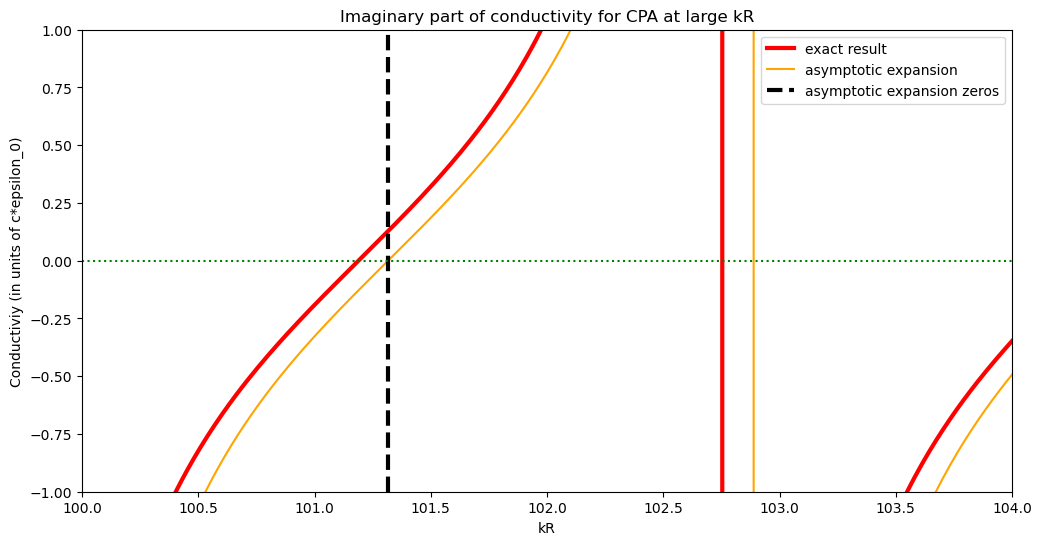

In [11]:
x_1 = 100
x_2 = 104
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(x, sigmas[1, :], color="red", linewidth=3, label="exact result")
ax.plot(x, sigmas_asymptotic.imag, color="orange", label="asymptotic expansion")
ax.set_ylim(-1, 1)
ax.vlines([pi/4/m]+ pi * linspace(1, 1000, 1000)/m, -1, 1, color="black", linestyle="dashed", linewidth=3, label="asymptotic expansion zeros")
ax.set_xlim(x_1, x_2);
ax.hlines([0], x_1, x_2, linestyle="dotted", color="green")
ax.set_xlabel("kR")
ax.set_ylabel("Conductiviy (in units of c*epsilon_0)");
ax.set_title("Imaginary part of conductivity for CPA at large kR");
ax.legend();

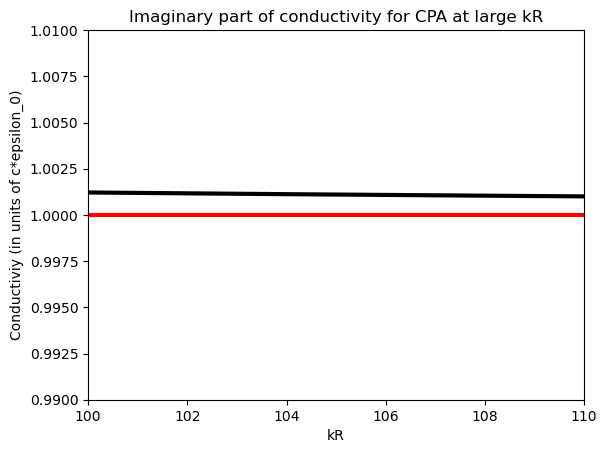

In [12]:
plt.plot(x, sigmas[0, :], color="black", linewidth=3)
plt.plot(x, sigmas_asymptotic.real, color="red", linewidth=3)

#plt.vlines([-pi/4/m]+ pi * linspace(1, 1000, 1000)/m, -1, 1, color="black", linestyle="dashed", linewidth=3)
plt.xlim(100, 110);
plt.ylim(0.99, 1.01)
plt.xlabel("kR")
plt.ylabel("Conductiviy (in units of c*epsilon_0)");
plt.title("Imaginary part of conductivity for CPA at large kR");

In [159]:
M = 1000
epsilon = 1
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [160]:
l = 1
j_y = jv(l, y); j_x = jv(l, x);

y_x = yv(l, x); 

j_yprime = jvp(l, y);
j_xprime = jvp(l, x);

y_xprime = yvp(l, x)

prefac = 1/(j_yprime*(j_xprime**2+y_xprime**2))
mat = np.array([[y_xprime, j_xprime], [-j_xprime, y_xprime]])
vec = np.array([j_x*j_yprime-m*j_xprime*j_y, m*j_y*y_xprime-y_x*j_yprime])

In [161]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)
sigma_real = sigmas[0, :]
sigma_imaginary = sigmas[1, :]
quasistatic_dispersion = (1+epsilon)*x/l

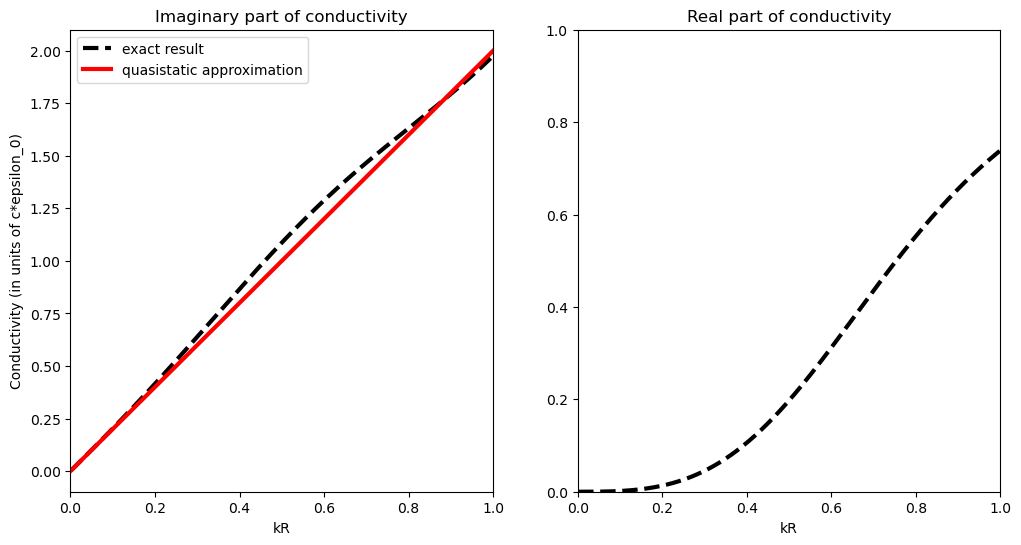

In [162]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, sigma_imaginary, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.plot(x, quasistatic_dispersion, label="quasistatic approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.set_xlim(0, 1)
#ax1.set_ylim(0, 2)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.legend();

ax2.plot(x, sigma_real, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 1)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");


### We verify that the conductivity corresponds to CPA

In [158]:
g_omegas = -1j*(sigma_real + 1j*sigma_imaginary)
numerator = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)-jvp(l, y, 1) * hankel2(l, x) - g_omegas*jvp(l, y, 1)*hl2_prime(l, x)
denominator = jvp(l, y, 1) * hankel1(l, x) + g_omegas*jvp(l, y, 1)*hl1_prime(l, x) - sqrt(epsilon) * jv(l, y) * hl1_prime(l, x)
s = numerator/denominator
print("Maximum |s|^2: ", (abs(s)**2).max())

Maximum |s|^2:  1.4444220925667755e-20


In [38]:
hbar = 6.67*1e-16 # hbar in eV*seconds
tau = 6.4*1e-13 # scattering time in seconds
c = 3*10**17; # speed of light in nanometers per second
alpha = 1/137; # fine structure constant

In [39]:
E_F = (hbar/tau)*(sigma_real**2+sigma_imaginary**2)/(4*sigma_real)/alpha;
a = c*tau*x*sigma_real/sigma_imaginary;

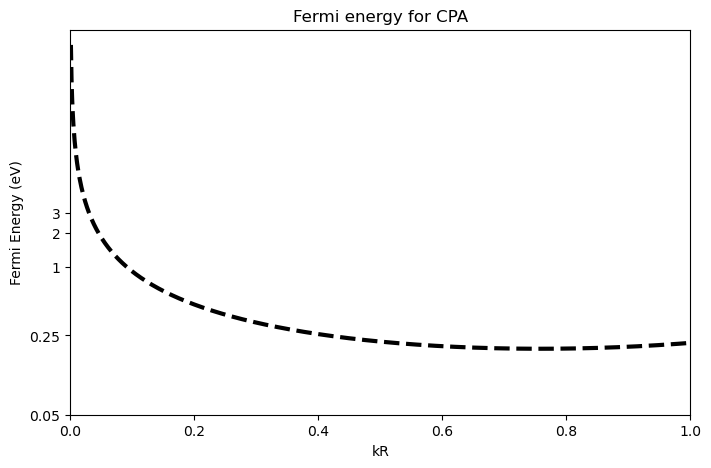

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, log(E_F), color="black", linestyle="dashed", linewidth=3)
ax.set_yticks([log(0.05), log(0.25), log(1), log(2), log(3)], [0.05, 0.25, 1, 2, 3])
#ax.set_ylim(log(0.05), log(3));
ax.set_xlim(0, 1)
ax.set_xlabel("kR");
ax.set_ylabel("Fermi Energy (eV)");
ax.set_title("Fermi energy for CPA");

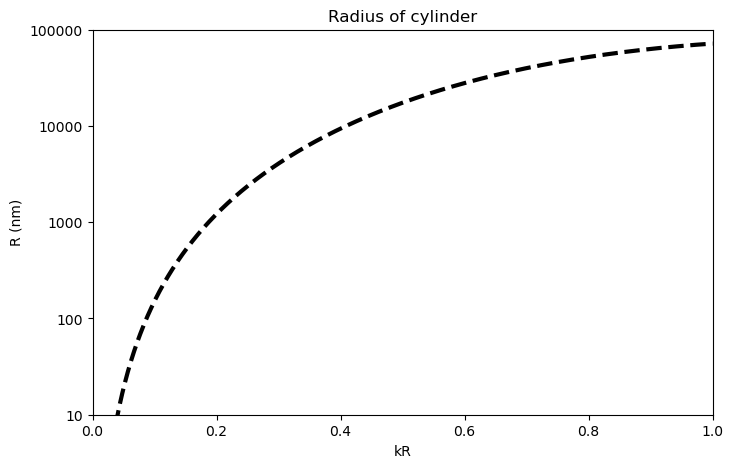

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, log(a), color="black", linestyle="dashed", linewidth=3)
ax.set_yticks([log(1e1), log(1e2), log(1e3), log(1e4), log(1e5)], [10, 100, 1000, 10000, 100000])
ax.set_ylim(log(1e1), log(1e5));
ax.set_xlim(0, 1)
ax.set_xlabel("kR");
ax.set_ylabel("R (nm)");
ax.set_title("Radius of cylinder");

### We verify that graphene gives the correct conductivity at those Fermi energies and frequencies

In [127]:
omega = c*x/a
graphene_cpa_sigmas = 4*1j*alpha*E_F/(hbar*(omega+1j/tau))
print("Maximum deviation from CPA conductivity (in normalized absolute value): ", abs((graphene_cpa_sigmas - sigma_real - 1j*sigma_imaginary)/graphene_cpa_sigmas).max())

Maximum deviation from CPA conductivity (in normalized absolute value):  6.418744983757189e-16


### Now we find the bandwidth for CPA

In [142]:
omega_range = linspace(1, 20, M)*1e12 # frequency in Hertz 
l = 1
real_epsilon = 1
epsilon = real_epsilon 

idxs = [500, 600, 700, 800, 900]
sqrds = zeros((len(idxs), M))
for (sq_idx, idx) in enumerate(idxs):
    sigma_range = 4*1j*alpha*E_F[idx]/(hbar*(omega_range+1j/tau)) # Graphene conductivity over the frequency range
    g_omega_range = -1j*sigma_range
    x_range = omega_range * a[idx]/c
    y_range = x_range * sqrt(epsilon) # epsilonkR in the sphere
    numerator = sqrt(epsilon) * jv(l, y_range) * hl2_prime(l, x_range)-jvp(l, y_range, 1) * hankel2(l, x_range) - g_omega_range*jvp(l, y_range, 1)*hl2_prime(l, x_range)
    denominator = jvp(l, y_range, 1) * hankel1(l, x_range) + g_omega_range*jvp(l, y_range, 1)*hl1_prime(l, x_range) - sqrt(epsilon) * jv(l, y_range) * hl1_prime(l, x_range)
    sqrds[sq_idx, :] = abs(numerator/denominator)**2

In [143]:
print("Minimum |s|^2: ", sqrds.min((1)))

Minimum |s|^2:  [9.88155253e-07 1.26336835e-05 9.12544359e-06 2.38536127e-05
 5.55746354e-06]


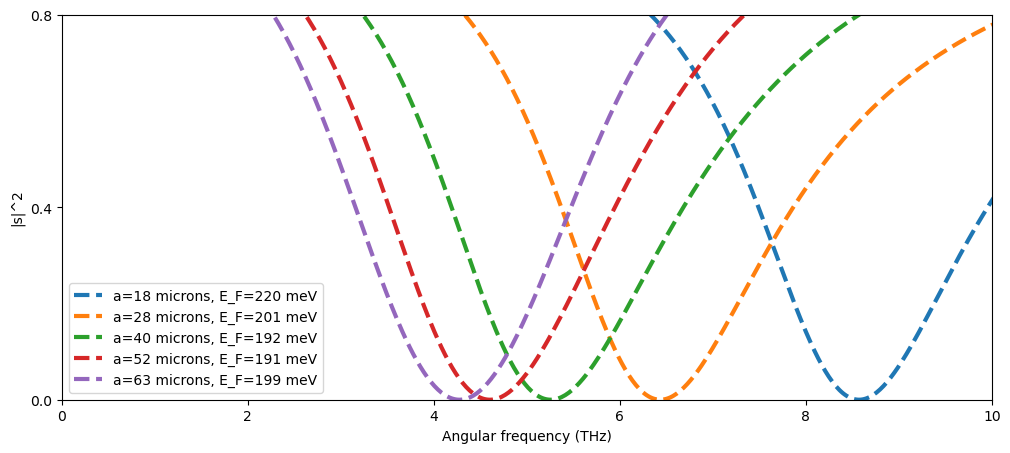

In [144]:
fig, ax = plt.subplots(figsize=(12, 5))
for (sq_idx, idx) in enumerate(idxs):
    ax.plot(omega_range/1e12, sqrds[sq_idx], linestyle="dashed", linewidth=3, label=f"a={round(a[idx]/1e3)} microns, E_F={round(E_F[idx]*1e3)} meV")
ax.set_ylim(0, 0.8)
ax.set_yticks([0, 0.4, 0.8])
ax.set_xlim(0, 10);
ax.set_xlabel("Angular frequency (THz)");
ax.set_ylabel("|s|^2");
ax.legend();

### Radiative ($E=E_z$) modes

In [145]:
M = 1000
epsilon = 4
x = linspace(100, 110, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [146]:
l = 5
j_y = jv(l, y); j_x = jv(l, x);

y_x = yv(l, x); 

j_yprime = jvp(l, y);
j_xprime = jvp(l, x);

y_xprime = yvp(l, x)

prefac = 1/(j_y*(j_x**2+y_x**2))
mat = np.array([[y_x, j_x], [-j_x, y_x]])
vec = np.array([m*j_x*j_yprime-j_xprime*j_y, j_y*y_xprime-m*y_x*j_yprime])

In [147]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)

In [148]:
asymptotic_denom = (-1)**(l+1)+1j*exp(2*1j*y)
asymptotic_num = (-1)**(l+1)*(1-m)+1j*(m+1)*exp(2*1j*y)
sigmas_asymptotic = asymptotic_num/asymptotic_denom 

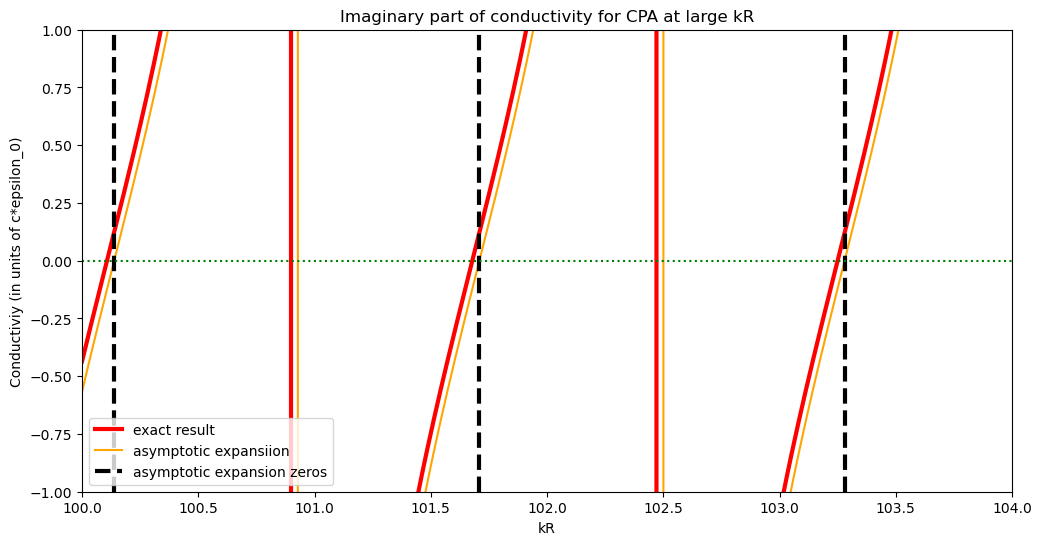

In [149]:
x_1 = 100
x_2 = 104
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(x, sigmas[1, :], color="red", linewidth=3, label="exact result")
ax.plot(x, sigmas_asymptotic.imag, color="orange", label="asymptotic expansiion")
ax.set_ylim(-1, 1)
ax.vlines([-pi/4/m]+ pi * linspace(1, 1000, 1000)/m, -1, 1, color="black", linestyle="dashed", linewidth=3, label="asymptotic expansion zeros")
ax.hlines([0], x_1, x_2, linestyle="dotted", color="green")
ax.set_xlim(x_1, x_2);
ax.set_xlabel("kR")
ax.set_ylabel("Conductiviy (in units of c*epsilon_0)");
ax.set_title("Imaginary part of conductivity for CPA at large kR");
ax.legend();

In [163]:
M = 1000
epsilon = 1
x_1 = 1e-3
x_2 = 5e-3
x = linspace(x_1, x_2, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [164]:
l = 1
j_y = jv(l, y); j_x = jv(l, x);

y_x = yv(l, x); 

j_yprime = jvp(l, y);
j_xprime = jvp(l, x);

y_xprime = yvp(l, x)

prefac = 1/(j_y*(j_x**2+y_x**2))
mat = np.array([[y_x, j_x], [-j_x, y_x]])
vec = np.array([m*j_x*j_yprime-j_xprime*j_y, j_y*y_xprime-m*y_x*j_yprime])

In [165]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)
sigma_real = sigmas[0, :]
sigma_imaginary = sigmas[1, :]

In [166]:
sigma = sigmas[:, np.argmin(np.abs(x-0.1))]

In [167]:
small_cylinder_dispersion = -(2*l)/x

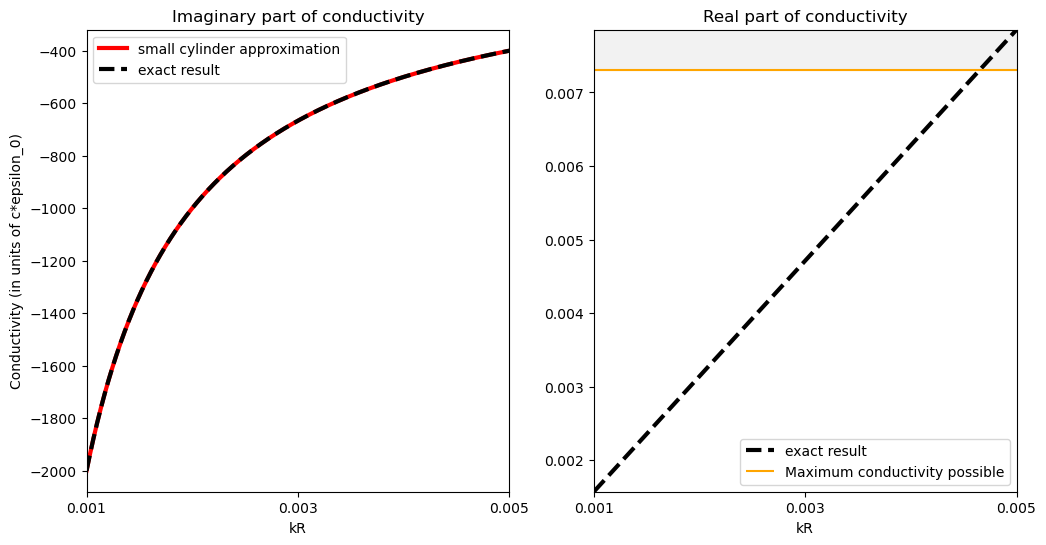

In [168]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, small_cylinder_dispersion, label="small cylinder approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.plot(x, sigma_imaginary, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.set_xlim(x_1, x_2)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.set_xticks([x_1, (x_1+x_2)/2, x_2])
ax1.legend();

ax2.plot(x, sigma_real, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.fill([x_1, x_1, x_2, x_2], [alpha, 2*alpha, 2*alpha, alpha], color="grey", alpha=0.1)
ax2.set_xlim(x_1, x_2)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");
ax2.hlines([alpha], x_1, x_2, label="Maximum conductivity possible", color="orange")
ax2.set_xticks([x_1, (x_1+x_2)/2, x_2]);
ax2.set_ylim(sigma_real.min(), sigma_real.max())
ax2.legend();

In [169]:
E_F_1 = (hbar/tau)*(alpha+sqrt(alpha**2-sigma_real**2))/(2*sigma_real);
E_F_2 = (hbar/tau)*(alpha-sqrt(alpha**2-sigma_real**2))/(2*sigma_real);

a_1 = c*x*hbar/(2*E_F_1);
a_2 = c*x*hbar/(2*E_F_2);

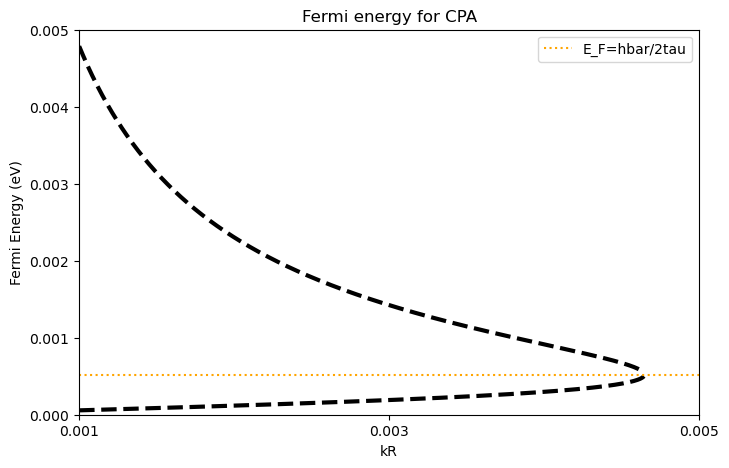

In [170]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, E_F_1, color="black", linestyle="dashed", linewidth=3)
ax.plot(x, E_F_2, color="black", linestyle="dashed", linewidth=3)

ax.set_xticks([x_1, (x_1+x_2)/2, x_2])
ax.set_xlim(x_1, x_2)
ax.set_ylim(0, 0.005)
ax.set_xlabel("kR");
ax.set_ylabel("Fermi Energy (eV)");
ax.hlines([hbar/(2*tau)], x_1, x_2, linestyle="dotted", color="orange", label="E_F=hbar/2tau")
ax.legend()
ax.set_title("Fermi energy for CPA");

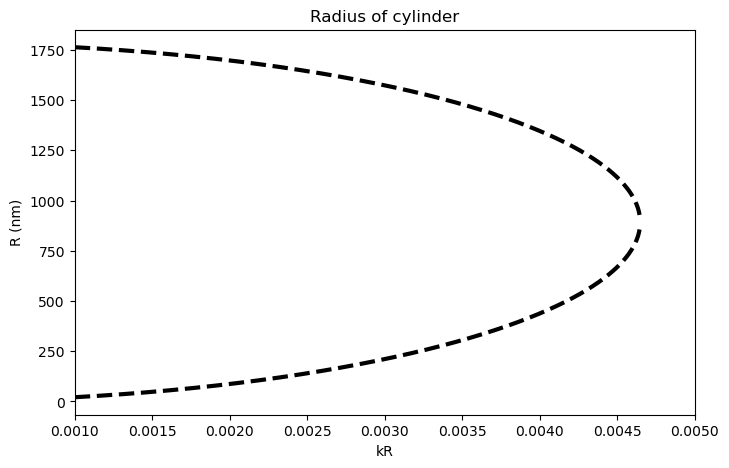

In [171]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, a_1, color="black", linestyle="dashed", linewidth=3)
ax.plot(x, a_2, color="black", linestyle="dashed", linewidth=3)

#ax.set_yticks([log(1e1), log(1e2), log(1e3), log(1e4), log(1e5)], [10, 100, 1000, 10000, 100000])
#ax.set_ylim(log(1e1), log(1e5));
ax.set_xlim(x_1, x_2)
#ax.set_ylim(10, 1000)
ax.set_xlabel("kR");
ax.set_ylabel("R (nm)");
ax.set_title("Radius of cylinder");